<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Unsupervised K-Means Clustering of SY Residential Building Stock

## Notebook Overview

The notebook contains two main analytical passes: an initial exploratory pass followed by a cleaner, structured clustering workflow.

### 1. Exploratory Pass

The first section represents an exploratory stage of the analysis. The data are loaded and undergo initial cleaning, including missing-value handling, type conversion, and manual min-max normalization of the three clustering features.

A preliminary `KMeans` model with `n_clusters=10` is fitted to explore the structure of the dataset. The resulting clusters are visualized using 3D scatter plots from different viewing angles. An elbow curve is then generated by evaluating cluster counts from 1 to 20, followed by an exploratory model using `k=2`.

This section is intentionally exploratory and contains some rough or redundant elements, including duplicate imports, copy-and-paste code, and a stray cell that renames columns to `premise_floor_count`, `property_age_years`, and `gross_area`.

### 2. Structured Clustering Pass

The second section provides the main, cleaner analytical workflow and is organized into the following stages:

1. **Prepare the data** — select the clustering features, convert them to numeric values, and remove observations with missing values.
2. **Inspect feature distributions** — examine descriptive statistics and visualize the distributions of property age, floor count, and gross area.
3. **Normalize the features** — apply `MinMaxScaler` so that variables with different numerical scales contribute more equally to the K-means distance calculations.
4. **Evaluate different numbers of clusters** — fit K-means models for `k = 2–9` and calculate inertia, silhouette score, Calinski-Harabasz score, and Davies-Bouldin score. Due to the large dataset size, computationally expensive validation metrics are calculated using a representative sample.
5. **Visualize model selection** — generate elbow and silhouette-score plots to assess the appropriate number of clusters.
6. **Select the final number of clusters** — use the clustering metrics as supporting evidence while selecting `k=2` for the final analysis.
7. **Fit the final K-means model** — apply K-means with two clusters to the complete normalized dataset and assign each property a cluster label.
8. **Profile and visualize the clusters** — report cluster sizes and percentages, calculate per-cluster summary statistics, and use box plots, histograms, and 3D scatter plots to compare the resulting groups.
9. **Evaluate the final clustering** — calculate the final silhouette score using a representative sample and produce a summary table of the main clustering results.

### Overall Purpose

The structured section provides the main reproducible workflow for identifying residential building groups based on **property age, floor count, and gross area**. The exploratory section documents the initial investigation, while the structured section provides the cleaner analysis used for interpreting and evaluating the final clustering results.

### Potential for real-world application

This notebook demonstrates an end-to-end K-means clustering workflow applied to residential building stock data for South Yorkshire. It is useful for:

- **Building stock segmentation** — grouping properties by age, floor count, and floor area to identify natural categories within a housing dataset, without relying on predefined labels.
- **Retrofit and energy-policy planning** — property age and size are strong proxies for construction standards and heating demand, making this type of clustering a common first step in identifying candidate groups for energy-efficiency retrofit programmes.
- **Reference workflow for K-means clustering** — the notebook walks through the core stages of a clustering pipeline: feature engineering (encoding categorical fields, imputing missing values), normalization, model fitting, the elbow method for selecting the number of clusters, and 3D visualization of results, making it a useful reference or starting point for similar clustering tasks.

> **Note:** The notebook is exploratory in nature and includes some leftover code, unused imports, and inconsistent handling of normalized vs. unnormalized features across cells. It would benefit from cleanup and the addition of quantitative cluster-validity metrics (e.g. silhouette score) before being used as a production reference.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import pylab as pl
pd.options.mode.copy_on_write = True
pd.set_option('future.no_silent_downcasting', True)

In [2]:
df=pd.read_csv('./SourceFileClean/CSV_UKBe16_Resi_SouthYorkshire-clean.csv')

print (df.head())

  premise_age   premise_type  premise_floor_count  \
0   Post 1999  Semi-detached                  2.0   
1   1960-1979       Detached                  1.0   
2   1990-1999       Detached                  1.0   
3   1960-1979       Detached                  1.0   
4   1990-1999       Detached                  1.0   

                         bungalow  height  building_area  gross_area  
0                  Not a bungalow    10.2          245.2       490.4  
1      Bungalow (high confidence)     6.3          194.7       194.7  
2  Bungalow (moderate confidence)     7.1          128.1       128.1  
3  Bungalow (moderate confidence)     6.8          107.0       107.0  
4  Bungalow (moderate confidence)     4.9           98.7        98.7  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans, Birch, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Set plot design
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ---------------------------------------------------------
# Step 1: Load Dataset
# ---------------------------------------------------------

# Use the same import

# ---------------------------------------------------------
# Step 2: Numerical Conversion for 'premise_age' & 'premise_type'
# ---------------------------------------------------------

# A. Convert 'premise_age' to numerical representative mid-point years
age_band_to_year = {
    'Pre 1919': 1900,
    '1919-1944': 1931,
    '1945-1959': 1952,
    '1960-1979': 1970,
    '1980-1989': 1985,
    '1990-1999': 1995,
    'Post 1999': 2010
}

# Map age strings to numeric year; calculate property age in years (relative to 2026)
df['premise_age_numeric'] = df['premise_age'].map(age_band_to_year)
# Fallback for unmapped or missing values via median imputation downstream
CURRENT_YEAR = 2026
df['property_age_years'] = CURRENT_YEAR - df['premise_age_numeric']

# B. Convert 'bungalow' flag to numerical confidence scale
bungalow_map = {
    'Not a bungalow': 0.0,
    'Bungalow (moderate confidence)': 0.5,
    'Bungalow (high confidence)': 1.0
}
df['bungalow_numeric'] = df['bungalow'].map(bungalow_map)

# C. Specify feature groups
num_cols = ['property_age_years', 'premise_floor_count', 'height', 
            'building_area', 'gross_area', 'bungalow_numeric']
cat_cols = ['premise_type']

# ---------------------------------------------------------
# Step 3: Feature Engineering Pipeline (Encoding + Imputation + Scaling)
# ---------------------------------------------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Fit and transform dataset into a fully numerical feature matrix
X_processed = preprocessor.fit_transform(df)

# Retrieve feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_cols))
all_feature_names = num_cols + encoded_cat_cols

X_df = pd.DataFrame(X_processed, columns=all_feature_names)

print(f"Processed Feature Matrix Shape: {X_processed.shape}")

Processed Feature Matrix Shape: (614460, 16)


In [4]:
df = X_df

In [5]:
df.head(2)

,property_age_years,premise_floor_count,height,building_area,gross_area,bungalow_numeric,premise_type_Domestic outbuilding,premise_type_Enclosed end-terrace,premise_type_Enclosed mid-terrace,premise_type_End-terrace,premise_type_Flat,premise_type_Maisonette,premise_type_Mid-terrace,premise_type_Semi-detached,premise_type_Terrace,premise_type_Unknown
0,-2.528591,0.294003,1.141930,0.142237,1.745118,-0.239969,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.581652,-1.488007,-0.407914,-0.031625,0.315385,4.268489,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:

sub_df = X_df[['property_age_years', 'premise_floor_count', 'gross_area']]

print(type(sub_df))    # Should show <class 'pandas.core.frame.DataFrame'>
print(sub_df.head())

<class 'pandas.core.frame.DataFrame'>
   property_age_years  premise_floor_count  gross_area
0           -2.528591             0.294003    1.745118
1           -0.581652            -1.488007    0.315385
2           -1.798489            -1.488007   -0.006631
3           -0.581652            -1.488007   -0.108652
4           -1.798489            -1.488007   -0.148783


In [7]:
for col in sub_df.columns:
    # Ensure the column is treated as string before checking for nulls if it's 'premise_floor_count' to handle mixed types
    if col == 'premise_floor_count':
        sub_df[col] = sub_df[col].astype(str)

    if sub_df[col].isnull().any():
        mode_series = sub_df[col].mode()
        if not mode_series.empty:
            fill_value = mode_series[0]
        else:
            # Fallback for all-null columns - use a placeholder or consider dropping
            fill_value = 'Unknown' if col == 'premise_floor_count' else 0 # Use 0 for numeric columns, 'Unknown' for premise_floor_count

        # Use .loc for safe assignment
        sub_df[col] = sub_df[col].fillna(fill_value)


In [8]:
# Convert the premise_floor_count column to numeric, coercing errors to NaN
sub_df.loc[:, 'premise_floor_count'] = pd.to_numeric(sub_df['premise_floor_count'], errors='coerce')

# Impute remaining NaN values in 'premise_floor_count' with the mode after coercion
# Calculate mode on the potentially numeric column
mode_premise_floor_count_numeric = sub_df['premise_floor_count'].mode()

if not mode_premise_floor_count_numeric.empty:
    fill_value_numeric = mode_premise_floor_count_numeric[0]
else:
    # Fallback if all values are NaN after coercion
    fill_value_numeric = 0 # Choose an appropriate default like 0 or median

sub_df.loc[:, 'premise_floor_count'] = sub_df['premise_floor_count'].fillna(fill_value_numeric).astype(int)

sub_df.head()

,property_age_years,premise_floor_count,gross_area
0,-2.528591,0,1.745118
1,-0.581652,-1,0.315385
2,-1.798489,-1,-0.006631
3,-0.581652,-1,-0.108652
4,-1.798489,-1,-0.148783


In [9]:
from sklearn.cluster import KMeans

In [10]:
km = KMeans(n_clusters=10)
km.fit(sub_df)
predictions = km.predict(sub_df)
labels = km.labels_


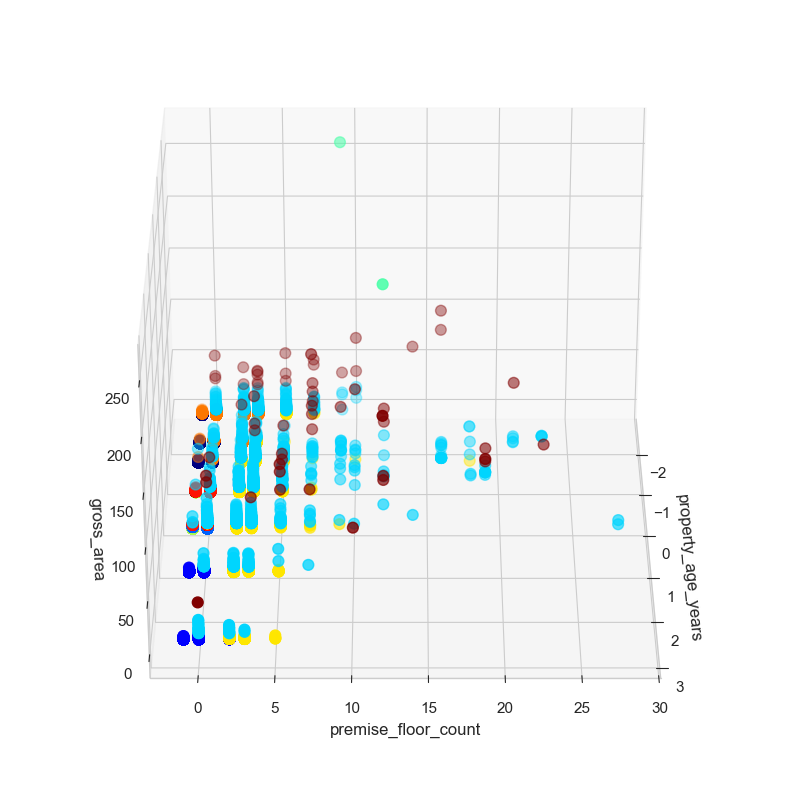

In [11]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')
x = np.array(sub_df['property_age_years'])
y = np.array(sub_df['premise_floor_count'])
z = np.array(sub_df['gross_area'])

ax.set_xlabel('property_age_years')
ax.set_ylabel('premise_floor_count')
ax.set_zlabel('gross_area')

ax.scatter(x,y,z, marker="o", c = predictions, s=60, cmap="jet")
ax.view_init(azim=0)
#print(ax.azim)
plt.show()

In [12]:
sub_df.loc[:, 'premise_floor_count'] = (sub_df['premise_floor_count'] - sub_df['premise_floor_count'].min())/(sub_df['premise_floor_count'].max()-sub_df['premise_floor_count'].min())


In [13]:
# Normalize property_age_years
sub_df['property_age_years'] = ((sub_df['property_age_years'] - sub_df['property_age_years'].min()) /
                  (sub_df['property_age_years'].max() - sub_df['property_age_years'].min())).astype(float)

# Normalize gross_area
sub_df['gross_area'] = ((sub_df['gross_area'] - sub_df['gross_area'].min()) /
                      (sub_df['gross_area'].max() - sub_df['gross_area'].min())).astype(float)

In [14]:
# Drop rows with NaN values as a temporary fix
sub_df_cleaned = sub_df.dropna()

km = KMeans(n_clusters=10, random_state=42, n_init=10) 
km.fit(sub_df_cleaned)
predictions = km.predict(sub_df_cleaned)
labels = km.labels_

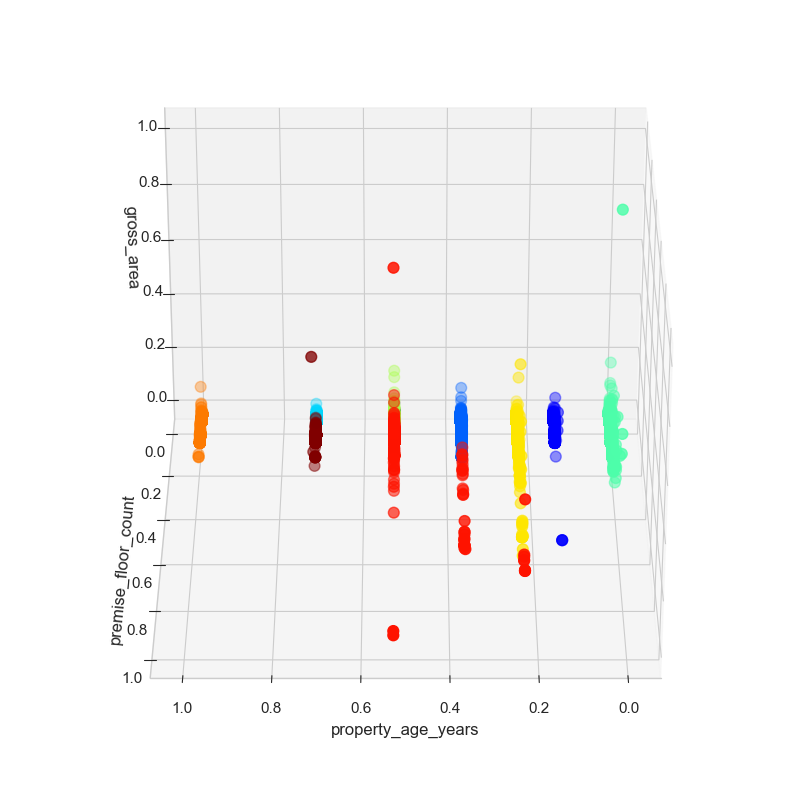

In [15]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')
x = np.array(sub_df['property_age_years'])
y = np.array(sub_df['premise_floor_count'])
z = np.array(sub_df['gross_area'])

ax.set_xlabel('property_age_years')
ax.set_ylabel('premise_floor_count')
ax.set_zlabel('gross_area')

ax.scatter(x,y,z, marker="o", c = predictions, s=60, cmap="jet")
ax.view_init(azim=90)
#print(ax.azim)
plt.show()

In [16]:
# Initialize the list for KMeans models
kmeans = []

# Create a range of cluster counts
N = range(1, 20)

for i in N:
    kmeans.append(KMeans(n_clusters=i, random_state=42,n_init=10))


In [17]:
score = []
# Drop rows with NaN values for fitting and scoring
sub_df_cleaned = sub_df.dropna()
for i in range(len(kmeans)):
    score.append(kmeans[i].fit(sub_df_cleaned).score(sub_df_cleaned))

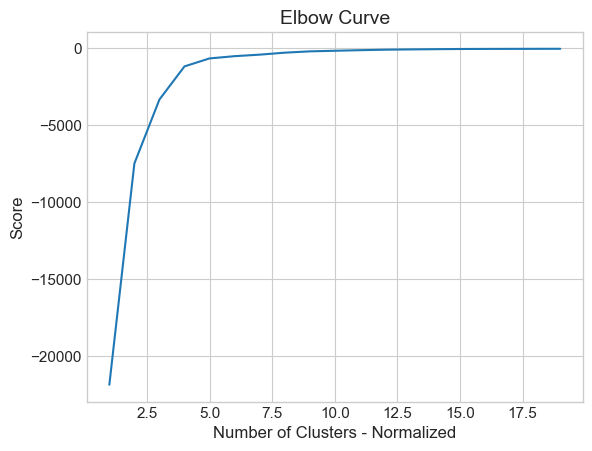

In [18]:
pl.plot(N,score)
pl.xlabel('Number of Clusters - Normalized')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [19]:
# Drop rows with NaN values as a temporary fix
sub_df_cleaned = sub_df.dropna()

km = KMeans(n_clusters=2, random_state=42, n_init=10) # Added random_state and n_init for reproducibility
km.fit(sub_df_cleaned)
y = km.predict(sub_df_cleaned)
labels_norm = km.labels_
# Drop rows with NaN values and create a copy
sub_df_cleaned = sub_df.dropna().copy()

km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(sub_df_cleaned)
y = km.predict(sub_df_cleaned)
labels_norm = km.labels_

# Use .loc for assignment to avoid warning
sub_df_cleaned.loc[:, 'Clusters_norm'] = y

print(sub_df_cleaned.head())


   property_age_years premise_floor_count  gross_area  Clusters_norm
0            0.000000            0.034483    0.008867              1
1            0.363636                 0.0    0.003464              1
2            0.136364                 0.0    0.002247              1
3            0.363636                 0.0    0.001862              1
4            0.136364                 0.0    0.001710              1


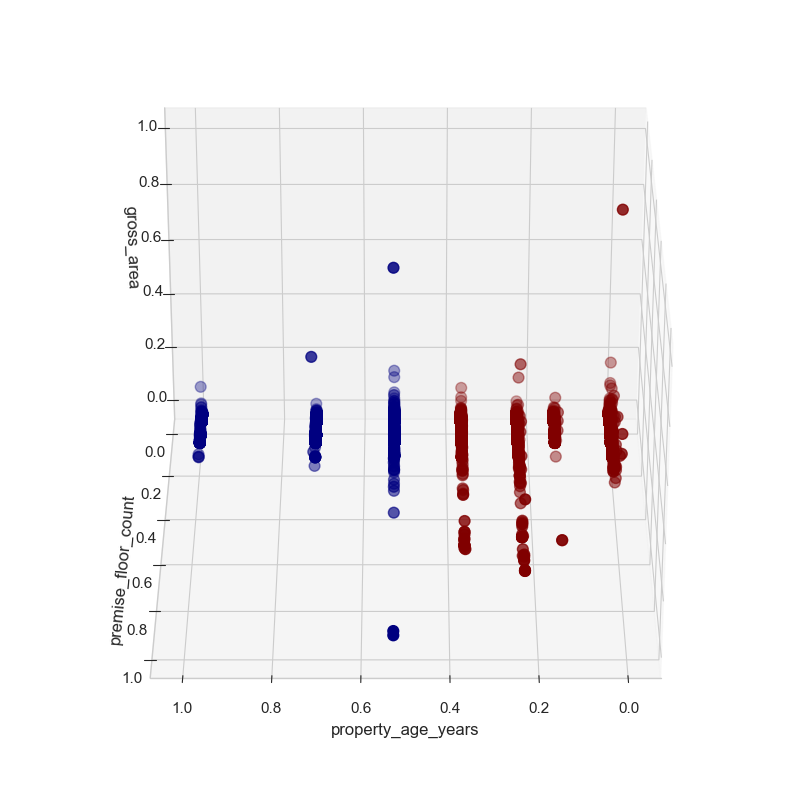

In [20]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# Use sub_df_cleaned for plotting, as it contains the cluster labels and has no NaNs
x = np.array(sub_df_cleaned['property_age_years'])
y = np.array(sub_df_cleaned['premise_floor_count'])
z = np.array(sub_df_cleaned['gross_area'])

ax.set_xlabel('property_age_years')
ax.set_ylabel('premise_floor_count')
ax.set_zlabel('gross_area')

# Use the 'Clusters_norm' column from sub_df_cleaned for coloring
ax.scatter(x,y,z, marker="o", c = sub_df_cleaned["Clusters_norm"], s=60, cmap="jet")
ax.view_init(azim=90)
#print(ax.azim)
plt.show()

# Before vs After Clustering

1. Feature distributions before clustering
2. Feature normalization
3. Choosing the number of clusters
    - Elbow method
    - Silhouette score
4. Final K-means model
5. Cluster sizes
6. Cluster profiles
7. Feature distributions by cluster
8. 3D visualization before clustering
9. 3D visualization after clustering
10. Cluster validity metrics
11. Interpretation

## 1. Prepare the clustering data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Features used for clustering
features = [
    "property_age_years",
    "premise_floor_count",
    "gross_area"
]

# Keep only required columns and remove missing values
cluster_df = df[features].copy()

for col in features:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")

cluster_df = cluster_df.dropna().copy()

print(f"Number of properties: {len(cluster_df):,}")
cluster_df.head()

Number of properties: 614,460


,property_age_years,premise_floor_count,gross_area
0,-2.528591,0.294003,1.745118
1,-0.581652,-1.488007,0.315385
2,-1.798489,-1.488007,-0.006631
3,-0.581652,-1.488007,-0.108652
4,-1.798489,-1.488007,-0.148783


## 2. Before clustering: inspect feature distributions

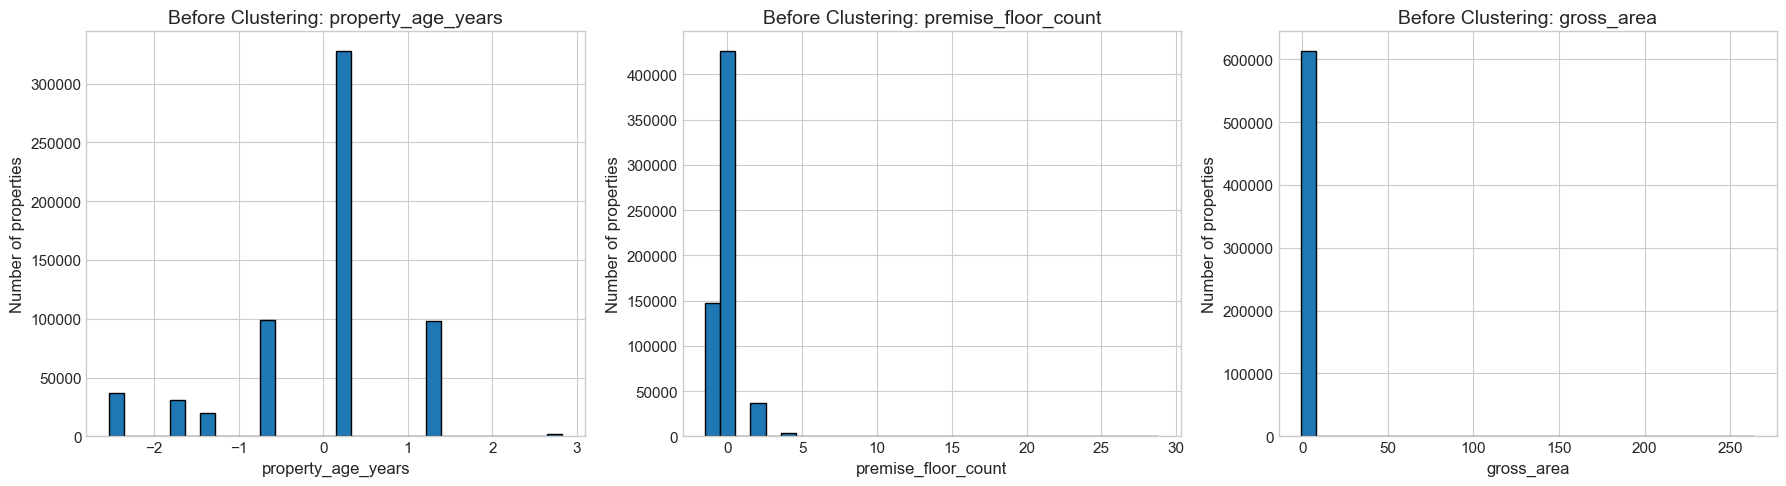

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, features):
    ax.hist(cluster_df[feature], bins=30, edgecolor="black")
    ax.set_title(f"Before Clustering: {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of properties")

plt.tight_layout()
plt.show()

In [23]:
# look at the summary statistics:
cluster_df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
property_age_years,614460.0,1.539359e-16,1.000001,-2.528591,-0.581652,0.294470,0.294470,2.825490
premise_floor_count,614460.0,6.808703e-17,1.000001,-1.488007,0.294003,0.294003,0.294003,28.806164
gross_area,614460.0,-3.700382e-17,1.000001,-0.601346,-0.256605,-0.106718,0.097323,264.032704


## 3. Normalize the features

In [24]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(cluster_df[features])

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features,
    index=cluster_df.index
)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
property_age_years,614460.0,0.472274,0.186774,0.0,0.363636,0.527273,0.527273,1.0
premise_floor_count,614460.0,0.049119,0.033010,0.0,0.058824,0.058824,0.058824,1.0
gross_area,614460.0,0.002272,0.003779,0.0,0.001303,0.001869,0.002640,1.0


## 4. Run K-means for different values of k

In [25]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

k_values = range(2, 10)

inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

# Sample for expensive validation metrics
sample_size = min(10000, len(X_scaled))

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

for k in k_values:

    print(f"Running k={k}...")

    # Fit K-means on ALL 614,460 properties
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    # Inertia from the complete dataset
    inertias.append(kmeans.inertia_)

    # Use sample for expensive validation metrics
    sample_labels = labels[sample_indices]

    silhouette_scores.append(
        silhouette_score(
            X_sample,
            sample_labels
        )
    )

    calinski_scores.append(
        calinski_harabasz_score(
            X_sample,
            sample_labels
        )
    )

    davies_scores.append(
        davies_bouldin_score(
            X_sample,
            sample_labels
        )

    )

    print(f"  Inertia: {kmeans.inertia_:,.0f}")
    print(f"  Silhouette: {silhouette_scores[-1]:.3f}")

Running k=2...
  Inertia: 7,714
  Silhouette: 0.653
Running k=3...
  Inertia: 3,541
  Silhouette: 0.689
Running k=4...
  Inertia: 1,378
  Silhouette: 0.792
Running k=5...
  Inertia: 860
  Silhouette: 0.816
Running k=6...
  Inertia: 541
  Silhouette: 0.874
Running k=7...
  Inertia: 395
  Silhouette: 0.879
Running k=8...
  Inertia: 296
  Silhouette: 0.892
Running k=9...
  Inertia: 230
  Silhouette: 0.929


## 5. Plot the elbow and silhouette scores

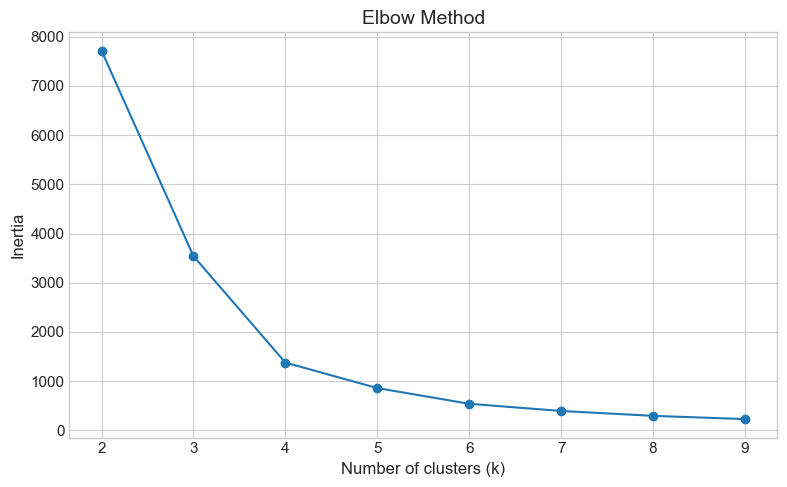

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_values, inertias, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method")

ax.set_xticks(list(k_values))

plt.tight_layout()
plt.show()

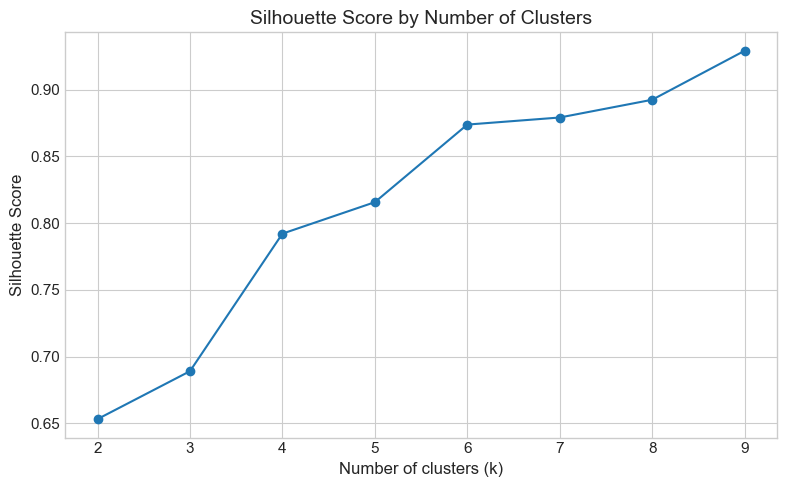

In [27]:
# And the silhouette score:

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_values, silhouette_scores, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by Number of Clusters")

ax.set_xticks(list(k_values))

plt.tight_layout()
plt.show()

## 6. Compare clustering metrics

In [28]:
metrics_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
    "calinski_harabasz_score": calinski_scores,
    "davies_bouldin_score": davies_scores
})

metrics_df

,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,2,7713.635829,0.653260,19137.517859,0.636738
1,3,3540.643319,0.689124,27238.450441,0.384655
2,4,1377.978825,0.792095,51888.764939,0.372338
3,5,859.768937,0.815673,65270.739567,0.327247
4,6,540.821738,0.873755,85632.460316,0.263863
5,7,394.672946,0.879058,97112.904499,0.233290
6,8,295.732340,0.892351,113779.426326,0.175710
7,9,229.624236,0.929036,130807.518627,0.171760


In [29]:
# identify the best silhouette score with:

best_k = metrics_df.loc[
    metrics_df["silhouette_score"].idxmax(),
    "k"
]

print(f"Best k according to silhouette score: {best_k}")

Best k according to silhouette score: 9


## 7. Fit the final model

In [30]:
final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

cluster_df["Clusters_norm"] = cluster_labels

In [31]:
# Check cluster sizes:

cluster_counts = (
    cluster_df["Clusters_norm"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

Clusters_norm
0    186205
1    428255
Name: count, dtype: int64


## 8. Compare cluster sizes

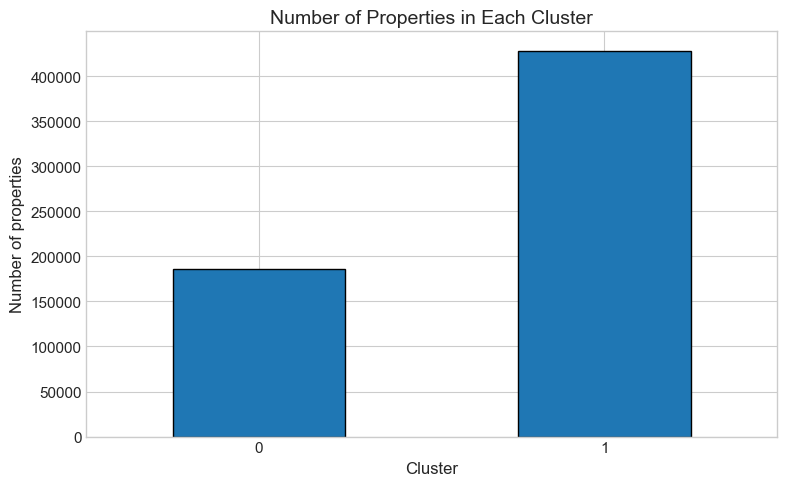

In [32]:
cluster_counts.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.xlabel("Cluster")
plt.ylabel("Number of properties")
plt.title("Number of Properties in Each Cluster")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
# calculate percentages:

cluster_percentages = (
    cluster_df["Clusters_norm"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

print(cluster_percentages)

Clusters_norm
0    30.3
1    69.7
Name: proportion, dtype: float64


## 9. Create cluster profiles

In [34]:
cluster_profile = (
    cluster_df
    .groupby("Clusters_norm")[features]
    .agg(["count", "mean", "median", "std"])
)

cluster_profile

property_age_years                                \
                           count      mean    median       std   
Clusters_norm                                                    
0                         186205 -1.242130 -0.581652  0.780437   
1                         428255  0.540077  0.294470  0.455460   

              premise_floor_count                               gross_area  \
                            count      mean    median       std      count   
Clusters_norm                                                                
0                          186205  0.261302  0.294003  0.939555     186205   
1                          428255 -0.113614  0.294003  1.004183     428255   

                                             
                   mean    median       std  
Clusters_norm                                
0              0.239883  0.013192  1.423353  
1             -0.104301 -0.142981  0.719744

In [35]:
# A cleaner summary is:

cluster_summary = (
    cluster_df
    .groupby("Clusters_norm")
    .agg(
        properties=("property_age_years", "size"),
        mean_age=("property_age_years", "mean"),
        median_age=("property_age_years", "median"),
        mean_floors=("premise_floor_count", "mean"),
        median_floors=("premise_floor_count", "median"),
        mean_area=("gross_area", "mean"),
        median_area=("gross_area", "median")
    )
    .round(2)
)

cluster_summary

,properties,mean_age,median_age,mean_floors,median_floors,mean_area,median_area
Clusters_norm,,,,,,,
0,186205,-1.24,-0.58,0.26,0.29,0.24,0.01
1,428255,0.54,0.29,-0.11,0.29,-0.10,-0.14


## 10. After clustering: box plots

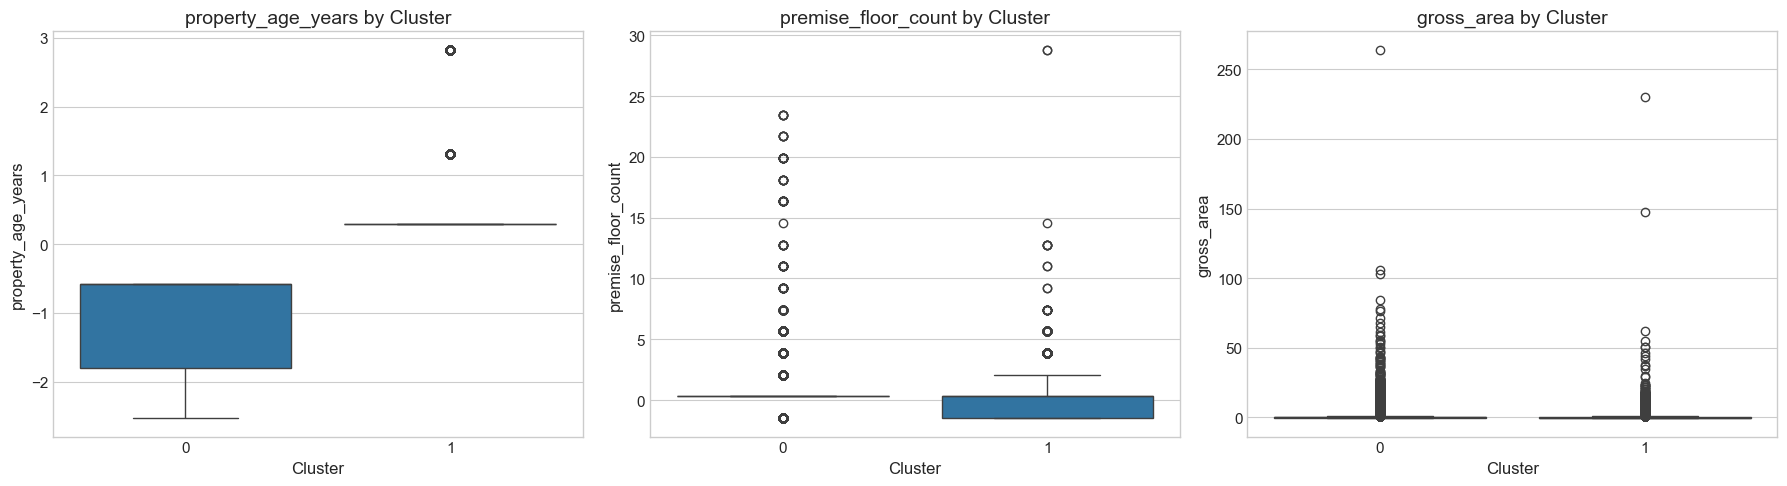

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, features):
    sns.boxplot(
        data=cluster_df,
        x="Clusters_norm",
        y=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature} by Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 11. Compare distributions by cluster

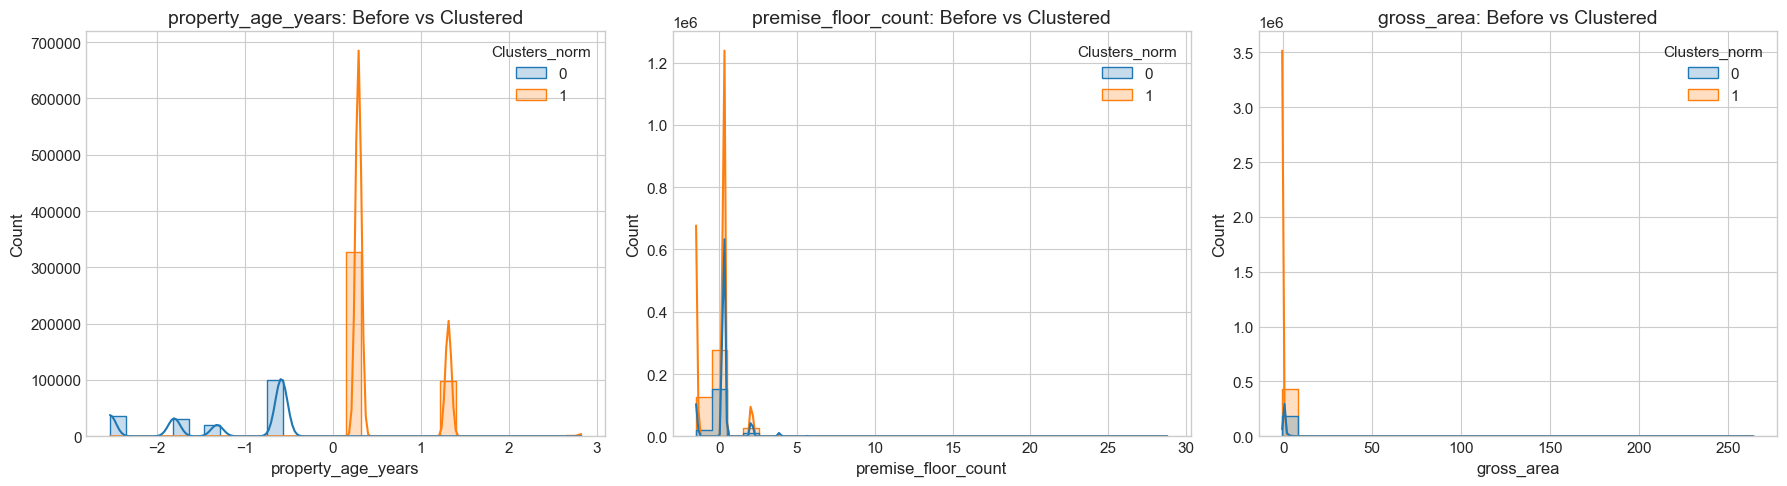

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, features):
    sns.histplot(
        data=cluster_df,
        x=feature,
        hue="Clusters_norm",
        bins=30,
        kde=True,
        element="step",
        ax=ax
    )
    
    ax.set_title(f"{feature}: Before vs Clustered")
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

## 12. 3D plot before clustering

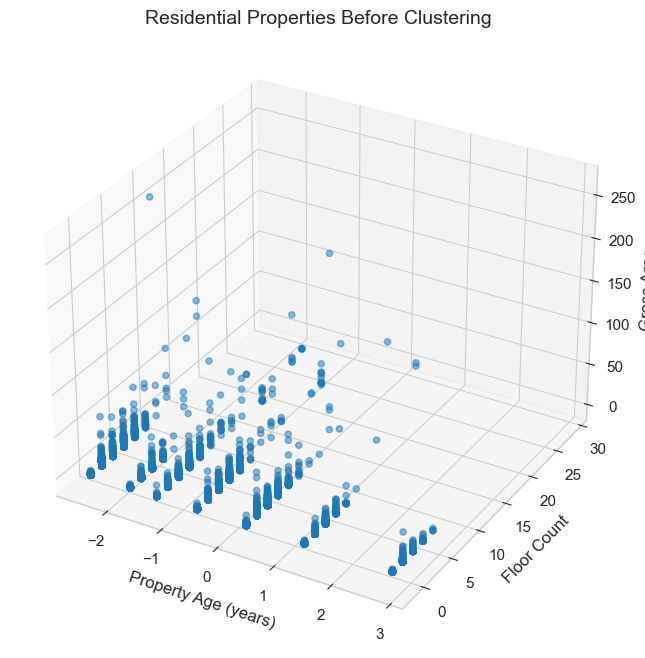

In [38]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    cluster_df["property_age_years"],
    cluster_df["premise_floor_count"],
    cluster_df["gross_area"],
    alpha=0.5
)

ax.set_xlabel("Property Age (years)")
ax.set_ylabel("Floor Count")
ax.set_zlabel("Gross Area")
ax.set_title("Residential Properties Before Clustering")

plt.show()

## 13. 3D plot after clustering

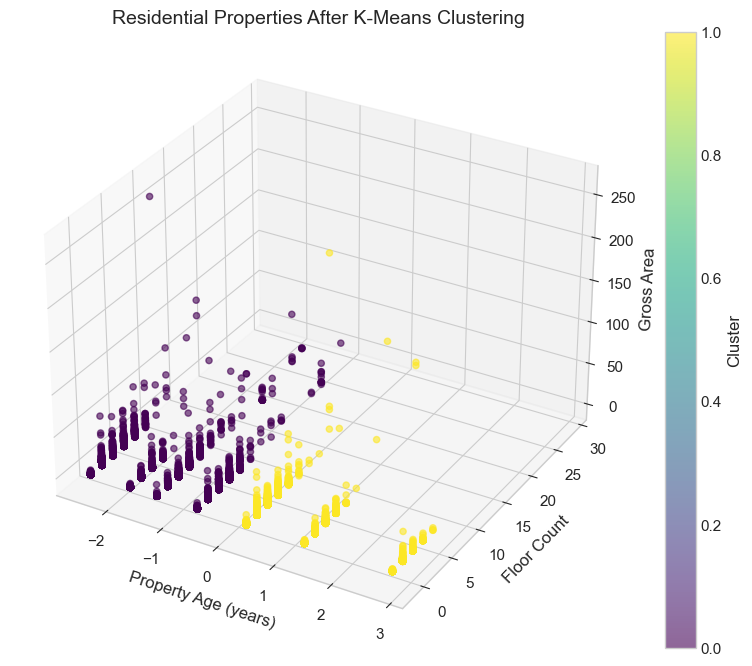

In [39]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    cluster_df["property_age_years"],
    cluster_df["premise_floor_count"],
    cluster_df["gross_area"],
    c=cluster_df["Clusters_norm"],
    cmap="viridis",
    alpha=0.6
)

ax.set_xlabel("Property Age (years)")
ax.set_ylabel("Floor Count")
ax.set_zlabel("Gross Area")
ax.set_title("Residential Properties After K-Means Clustering")

plt.colorbar(
    scatter,
    ax=ax,
    label="Cluster"
)

plt.show()

## 14. Evaluate the final clustering

In [40]:
# ============================================
# 14. Fast evaluation of final clustering
# ============================================

from sklearn.metrics import silhouette_score

# Use a small reproducible sample
sample_size = min(5000, len(X_scaled))

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]
labels_sample = cluster_labels[sample_indices]

# Calculate silhouette score on the sample
final_silhouette = silhouette_score(
    X_sample,
    labels_sample
)

print("Final Clustering Evaluation")
print("----------------------------")
print(f"Total properties:   {len(X_scaled):,}")
print(f"Evaluation sample:  {sample_size:,}")
print(f"Number of clusters: {final_k}")
print(f"Silhouette score:   {final_silhouette:.3f}")

Final Clustering Evaluation
----------------------------
Total properties:   614,460
Evaluation sample:  5,000
Number of clusters: 2
Silhouette score:   0.653


## 15. Compare raw vs normalized K-means

In [42]:
# ============================================
# 15. Compare clustered groups
# ============================================

# Add the final cluster labels to the original feature data
comparison_df = cluster_df[
    ["property_age_years", "premise_floor_count", "gross_area"]
].copy()

comparison_df["Cluster"] = cluster_labels

# Summary statistics by cluster
cluster_comparison = (
    comparison_df
    .groupby("Cluster")
    .agg(
        Properties=("property_age_years", "size"),
        Mean_Age=("property_age_years", "mean"),
        Median_Age=("property_age_years", "median"),
        Mean_Floors=("premise_floor_count", "mean"),
        Median_Floors=("premise_floor_count", "median"),
        Mean_Area=("gross_area", "mean"),
        Median_Area=("gross_area", "median")
    )
    .round(2)
)

cluster_comparison

,Properties,Mean_Age,Median_Age,Mean_Floors,Median_Floors,Mean_Area,Median_Area
Cluster,,,,,,,
0,186205,-1.24,-0.58,0.26,0.29,0.24,0.01
1,428255,0.54,0.29,-0.11,0.29,-0.10,-0.14


## 16. Final comparison table

In [44]:
# ============================================
# 16. Final clustering results
# ============================================

final_results = pd.DataFrame({
    "Metric": [
        "Total properties",
        "Number of clusters",
        "Validation sample",
        "Silhouette score"
    ],
    "Result": [
        f"{len(cluster_df):,}",
        final_k,
        f"{sample_size:,}",
        round(final_silhouette, 3)
    ]
})

final_results

,Metric,Result
0,Total properties,"614,460"
1,Number of clusters,2
2,Validation sample,"5,000"
3,Silhouette score,0.653


In [45]:
# Cluster size and percentage
cluster_sizes = (
    cluster_df["Clusters_norm"]
    .value_counts()
    .sort_index()
    .to_frame("Properties")
)

cluster_sizes["Percentage"] = (
    cluster_sizes["Properties"]
    / len(cluster_df)
    * 100
).round(2)

cluster_sizes

,Properties,Percentage
Clusters_norm,,
0,186205,30.3
1,428255,69.7
